In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


In [2]:
data = pd.read_csv("../Housing.csv")

In [3]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
data.drop(columns=['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'], axis=1, inplace=True)

In [5]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories'], dtype='object')

In [6]:
data.corr()

,price,area,bedrooms,bathrooms,stories
price,1.000000,0.535997,0.366494,0.517545,0.420712
area,0.535997,1.000000,0.151858,0.193820,0.083996
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165
stories,0.420712,0.083996,0.408564,0.326165,1.000000


<Axes: >

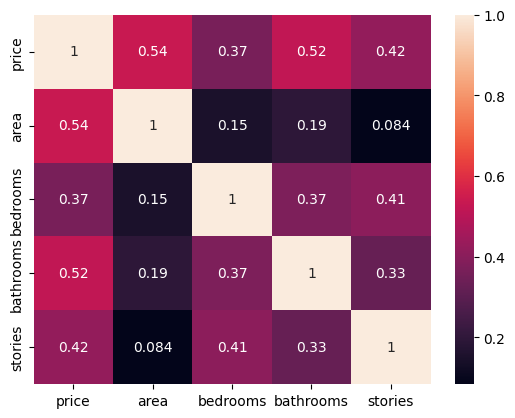

In [7]:
sns.heatmap(data=data.corr(), annot=True)

In [8]:
X = data.drop(columns="price", axis=1)
y=data["price"]
X, y

(     area  bedrooms  bathrooms  stories
 0    7420         4          2        3
 1    8960         4          4        4
 2    9960         3          2        2
 3    7500         4          2        2
 4    7420         4          1        2
 ..    ...       ...        ...      ...
 540  3000         2          1        1
 541  2400         3          1        1
 542  3620         2          1        1
 543  2910         3          1        1
 544  3850         3          1        2
 
 [545 rows x 4 columns],
 0      13300000
 1      12250000
 2      12250000
 3      12215000
 4      11410000
          ...   
 540     1820000
 541     1767150
 542     1750000
 543     1750000
 544     1750000
 Name: price, Length: 545, dtype: int64)

In [9]:
sc = StandardScaler()
sc.fit(X)
X= pd.DataFrame(sc.transform(X), columns=[ 'area', 'bedrooms', 'bathrooms', 'stories'])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
print(lr.score(X_test, y_test))
print("mae", mean_absolute_error(y_test, lr.predict(X_test)))
print("mse", mean_squared_error(y_test, lr.predict(X_test)))
print("rmse", root_mean_squared_error(y_test, lr.predict(X_test)))

0.5227515726361729
mae 911387.103260456
mse 1693790596490.8013
rmse 1301457.105129017


<BarContainer object of 4 artists>

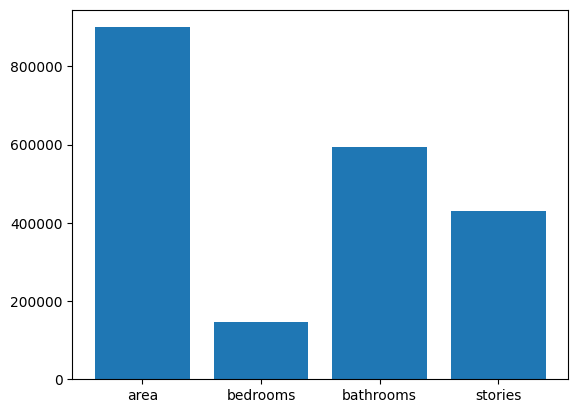

In [13]:
plt.bar(X.columns, lr.coef_)

In [ ]:
# Lasso Regression

la = Lasso(alpha=0.5)
la.fit(X_train, y_train)
la.score(X_test, y_test)
print("mae", mean_absolute_error(y_test, la.predict(X_test)))
print("mse", mean_squared_error(y_test, la.predict(X_test)))
print("rmse", root_mean_squared_error(y_test, la.predict(X_test)))

mae 911387.0168276656
mse 911387.0168276656
rmse 911387.0168276656


<BarContainer object of 4 artists>

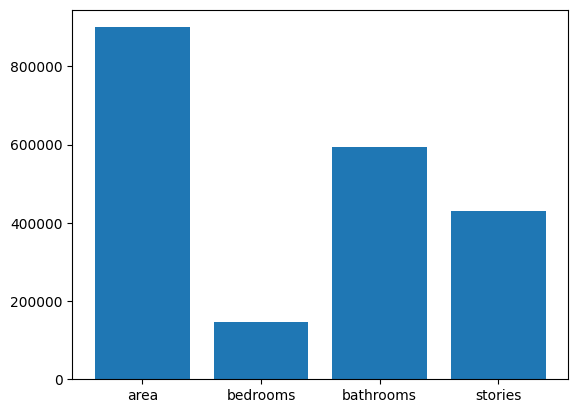

In [17]:
plt.bar(X.columns, la.coef_)

In [25]:
# Ridge 
ri = Ridge(alpha=1)
ri.fit(X_train, y_train)
ri.score(X_test, y_test)
print("mae", mean_absolute_error(y_test, ri.predict(X_test)))
print("mse", mean_squared_error(y_test, ri.predict(X_test)))
print("rmse", root_mean_squared_error(y_test, ri.predict(X_test)))

mae 910876.4585378396
mse 1692582496865.7437
rmse 1300992.8888605593


<BarContainer object of 4 artists>

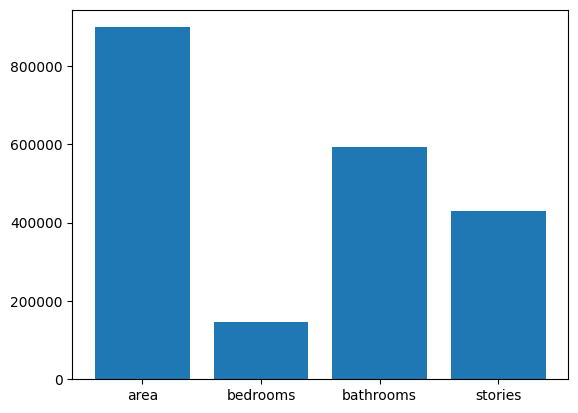

In [19]:
plt.bar(X.columns, ri.coef_)